# matplotlib - 2D and 3D plotting in Python

I am using the file created by Dr. J.R. Johansson (jrjohansson at gmail.com).

The latest version of his [IPython notebook](http://ipython.org/notebook.html) lecture is available at [http://github.com/jrjohansson/scientific-python-lectures](http://github.com/jrjohansson/scientific-python-lectures).

The other notebooks in this lecture series are indexed at [http://jrjohansson.github.io](http://jrjohansson.github.io).

In [ ]:
# This line configures matplotlib to show figures embedded in the notebook, 
# instead of opening a new window for each figure. More about that later. 
# If you are using an old version of IPython, try using '%pylab inline' instead.
%matplotlib inline

## Introduction

Matplotlib is an excellent 2D and 3D graphics library for generating scientific figures. Some of the many advantages of this library include:

* Easy to get started
* Support for $\LaTeX$ formatted labels and texts
* Great control of every element in a figure, including figure size and DPI. 
* High-quality output in many formats, including PNG, PDF, SVG, EPS, and PGF.
* GUI for interactively exploring figures *and* support for headless generation of figure files (useful for batch jobs).

One of the key features of matplotlib that I would like to emphasize, and that I think makes matplotlib highly suitable for generating figures for scientific publications is that all aspects of the figure can be controlled *programmatically*. This is important for reproducibility and convenient when one needs to regenerate the figure with updated data or change its appearance. 

More information at the Matplotlib web page: http://matplotlib.org/

To get started using Matplotlib in a Python program, either include the symbols from the `pylab` module (the easy way):

In [2]:
from pylab import *

or import the `matplotlib.pyplot` module under the name `plt` (the tidy way):

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

Matplotlib contains many submodules and a few basic functions stored directly in `matplotlib`. You can import the whole library, or just the submodule you need — almost everyone only ever needs `pyplot`.

A few submodules worth knowing exist, even if you rarely import them by name:

1. **pyplot** — the one you'll use constantly; creates and manages plots.
2. **axes** — the region where data actually gets drawn.
3. **figure** — the container that holds one or more axes.
4. **patches** — shapes: rectangles, circles, arrows.
5. **text** — annotations and labels.
6. **colors** — defining and converting colors.
7. **ticker** — customizing axis tick marks.
8. **gridspec** — complex, uneven subplot grids.
9. **animation** — frame-by-frame animated figures.

`pyplot` provides a MATLAB-like interface on top of all of this, which is why `plt.plot(...)` feels familiar if you've used MATLAB before.

In [ ]:
import numpy as np # We have imported the numpy library as np. This is a common convention in the Python community.
#It will create the test data for us. We will use this data to plot the graph.

## MATLAB-like API

The easiest way to get started with plotting using matplotlib is often to use the MATLAB-like API provided by matplotlib. 

It is designed to be compatible with MATLAB's plotting functions, so it is easy to get started with if you are familiar with MATLAB.

To use this API from matplotlib, we need to include the symbols in the `pylab` module: 

In [1]:
from pylab import *

**Why `figure()`, `plot()`, `xlabel()` work with no prefix here:**

`from pylab import *` is a *wildcard import*. `pylab` itself does roughly:

```python
from matplotlib.pyplot import *
from numpy import *
```

The `import *` dumps every function from `pyplot` (and numpy) straight into this notebook's namespace, unprefixed — so `figure()` is really `matplotlib.pyplot.figure()`, just imported under its bare name. Nothing mysterious, just hidden.

Compare this to `import matplotlib.pyplot as plt` (used earlier, and everywhere from the object-oriented API section onward): that only binds the name `plt`. Every function stays namespaced under it — `plt.figure()`, `plt.plot()` — so it can never silently overwrite a variable you already have.

That silent-overwrite risk is exactly why `from pylab import *` is now considered bad practice, and why the rest of this notebook (from the "matplotlib object-oriented API" section on) drops it in favor of `plt.`-prefixed calls.


### Example

A simple figure with MATLAB-like plotting API:

In [2]:
x = np.linspace(0, 5, 10)
y = x ** 2
print("Vaues of x:", x)
print("Values of y:", y)

Vaues of x: [0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]
Values of y: [ 0.          0.30864198  1.2345679   2.77777778  4.9382716   7.71604938
 11.11111111 15.12345679 19.75308642 25.        ]


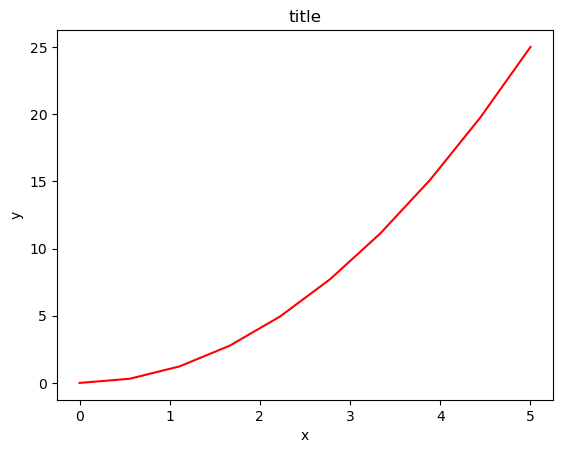

In [3]:
figure() #This line creates a new figure, so that the next plot command will be drawn in this new figure.
# If you don't call this function, the next plot command will be drawn in the current figure (if any).

plot(x, y, 'r')# r stands for red color. other colors are b(blue), g(green), c(cyan), m(magenta), y(yellow), k(black), w(white).
# 'r' here is shorthand for a *style string*. You can combine color + linestyle + marker in one short code,
# e.g. 'r--' (red dashed), 'go-' (green circles joined by a line), 'k:' (black dotted).
# The full linestyle/marker options are covered later in "Setting colors, linewidths, linetypes" -- 
# this is just the quick MATLAB-style shortcut.
xlabel('x')
ylabel('y')
title('title')
savefig('my_figure.png') # save BEFORE show() -- see note below
show() # display AFTER saving

**Why `savefig()` comes before `show()`:**

`show()` displays the figure and then, on most backends, closes or clears it once the window is dismissed (some backends reset the current-figure state right after rendering). If `savefig()` runs *after* `show()`, there's often no active figure left to save — you'll get a blank PNG.

**Rule of thumb: always save before you show.** Try swapping the order below to see the blank file for yourself.

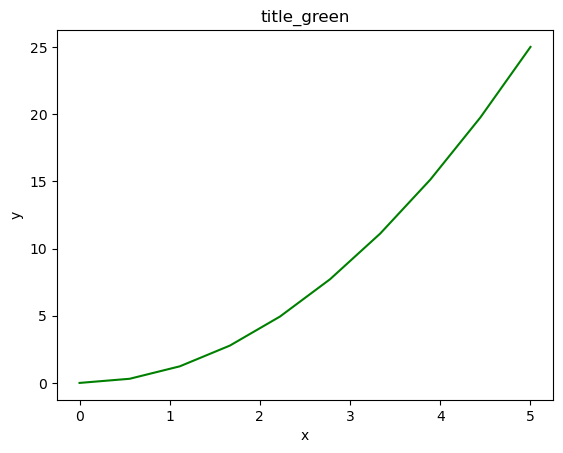

In [4]:
figure()
plot(x, y, 'g')  # green, solid line by default (no linestyle/marker code given)
xlabel('x')
ylabel('y')
title('title_green')
savefig('my_figure_green.png') # saved BEFORE show(), so this one will NOT be blank
show()

**`plot()`'s full signature:** `plot(*args, scalex=True, scaley=True, data=None, **kwargs)`

- `*args` — almost always two arrays: x-coordinates and y-coordinates. Can also take a single style string as a third positional argument, like `'r--'`, instead of using `color=`/`linestyle=` keywords separately.
- `scalex`, `scaley` — whether the axes auto-rescale to fit the new data.
- `data` — lets you pass column *names* (as strings) instead of raw arrays, if you're plotting from something like a pandas DataFrame.
- `**kwargs` — everything else: `color`, `linewidth`, `marker`, `markersize`, and more, covered in detail later.

Most of the plotting related functions in MATLAB are covered by the `pylab` module. For example, subplot and color/symbol selection:

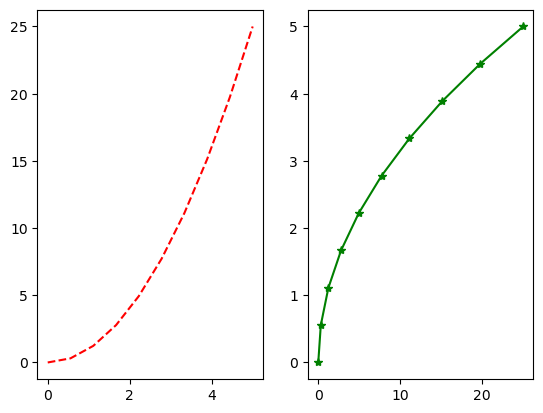

In [5]:
subplot(1,2,1)
# Subplot grid is specified as (nrows, ncols, index), where index starts at 1 in the upper left corner and increases to the right.
plot(x, y, 'r--')
# "--" indicates a dashed line. Other options include "-", "-.", ":", and "None" (no line).
subplot(1,2,2)
plot(y, x, 'g*-');

The good thing about the pylab MATLAB-style API is that it is easy to get started with if you are familiar with MATLAB, and it has a minimum of coding overhead for simple plots. 

However, I'd encourage not using the MATLAB compatible API for anything but the simplest figures.

Instead, I recommend learning and using matplotlib's object-oriented plotting API. It is remarkably powerful. For advanced figures with subplots, insets and other components it is very nice to work with. 

## Plotting data stored in a file

So far `x` and `y` were arrays we typed by hand. In real work, data almost always lives in a file first. Rather than trust some downloaded file whose contents you can't fully verify, let's do the *whole round trip ourselves*: generate data we know the exact shape of, save it in three common formats, then load each one back and plot it. That way, when a plot looks wrong, you'll know it's the loading step and not a mystery in the data.

In [6]:
# Generate synthetic data: a noisy sine wave, something with a known, checkable shape.
t = np.linspace(0, 4*np.pi, 200)
signal = np.sin(t) + 0.1 * np.random.randn(t.size)

data_out = np.column_stack([t, signal])  # two columns: t and signal, side by side
print(data_out.shape)  # (200, 2)

(200, 2)


### Format 1: `.dat` — whitespace-delimited, no header

`np.savetxt`'s default: space-separated columns, nothing else. Simple, but a file like this carries no information about what the columns *mean* — you have to remember, or document it separately.

In [10]:
np.savetxt('signal.dat', data_out)
# !head -n 3 signal.dat It is a unix command to display the first 3 lines of the file signal.dat. 
# It is commented out because it may not work on all systems, especially Windows.
np.savetxt('signal.dat', data_out)
with open('signal.dat') as f:
    for _ in range(3):
        print(f.readline(), end='')

0.000000000000000000e+00 4.242694768581749959e-02
6.314759102693051629e-02 1.036352502618657218e-01
1.262951820538610326e-01 2.407827201206594603e-01


Loading it back is exactly what we did with the Stockholm file — `genfromtxt` (or the stricter `np.loadtxt`, which is faster but fails on any malformed row) just reads columns of numbers.

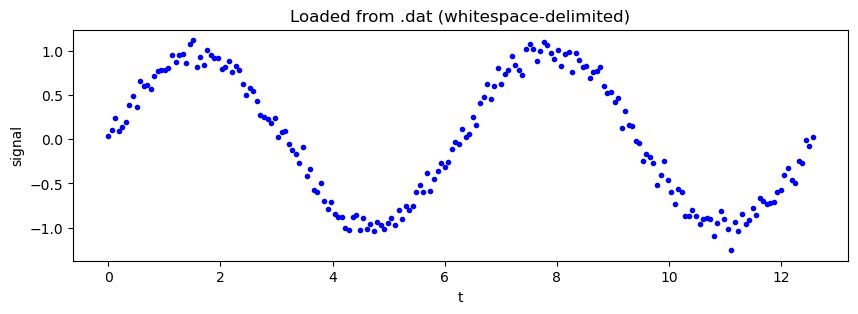

In [11]:
reloaded = np.genfromtxt('signal.dat')
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(reloaded[:, 0], reloaded[:, 1], 'b.')
ax.set_xlabel('t')
ax.set_ylabel('signal')
ax.set_title('Loaded from .dat (whitespace-delimited)');

### Format 2: `.csv` — comma-delimited, with a header row

This time we'll add a header naming the columns, and use a comma as the delimiter. Now the file documents itself — anyone opening it in Excel or a text editor immediately knows what each column is.

In [13]:
np.savetxt('signal.csv', data_out, delimiter=',', header='t,signal', comments='')
# !head -n 3 signal.csv.
# It is a unix command to display the first 3 lines of the file signal.csv. 
# It is commented out because it may not work on all systems, especially Windows.
with open('signal.csv') as f:
    for _ in range(3):
        print(f.readline(), end='') 
        

t,signal
0.000000000000000000e+00,4.242694768581749959e-02
6.314759102693051629e-02,1.036352502618657218e-01


To load a file *with* a header, tell `genfromtxt` about both the delimiter and the header row with `names=True` — this gives you back a structured array you can index **by column name** instead of by position, which is far less error-prone in longer scripts.

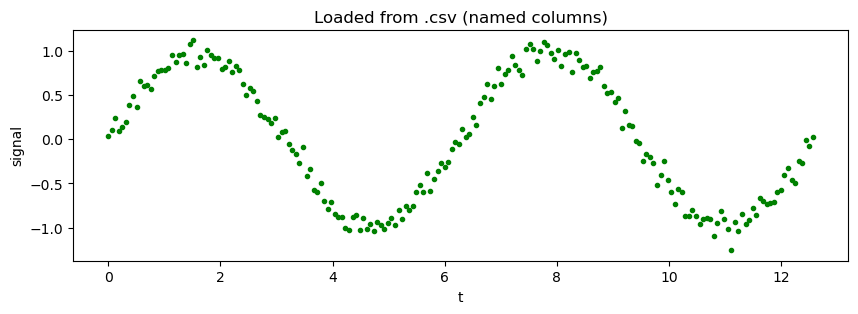

In [14]:
reloaded_csv = np.genfromtxt('signal.csv', delimiter=',', names=True)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(reloaded_csv['t'], reloaded_csv['signal'], 'g.')  # indexed by name, not reloaded_csv[:,1]
ax.set_xlabel('t')
ax.set_ylabel('signal')
ax.set_title('Loaded from .csv (named columns)');

### Format 3: `.txt` — same content as `.dat`, different extension

Here's the point this format is meant to prove: **the file extension is just a naming convention — numpy never looks at it.** What matters is the delimiter you tell the loader to expect. We'll save the identical whitespace-delimited content as `.dat` above, but name it `.txt`, and load it the exact same way.

In [15]:
np.savetxt('signal.txt', data_out)  # identical content and delimiter to signal.dat

reloaded_txt = np.genfromtxt('signal.txt')  # same loader call as the .dat file
print("Identical to the .dat version?", np.allclose(reloaded_txt, reloaded))

Identical to the .dat version? True


**The pattern, in three steps, regardless of extension:** *know your delimiter* (space, comma, tab...) → *know whether there's a header* → *load and plot like any other array*. `np.savetxt`/`np.loadtxt`/`np.genfromtxt` cover plain numeric data; reach for `pandas.read_csv` instead once a file mixes text and numbers, or has missing values you need to handle.

## The matplotlib object-oriented API

The main idea with object-oriented programming is to have objects that one can apply functions and actions on, and no object or program states should be global (such as the MATLAB-like API). The real advantage of this approach becomes apparent when more than one figure is created, or when a figure contains more than one subplot. 

To use the object-oriented API we start out very much like in the previous example, but instead of creating a new global figure instance we store a reference to the newly created figure instance in the `fig` variable, and from it we create a new axis instance `axes` using the `add_axes` method in the `Figure` class instance `fig`:    

False


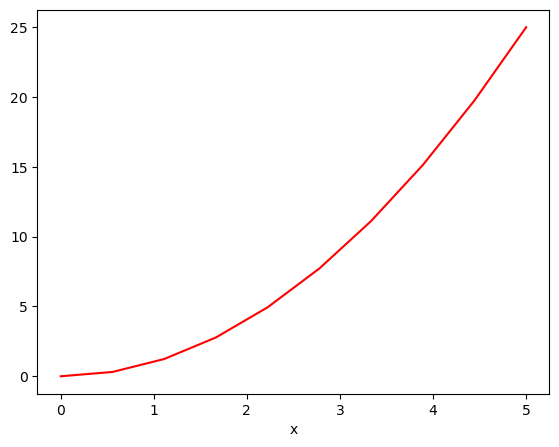

In [22]:
plt.close('all') 
fig = plt.figure()  # create an empty figure canvas on which to draw one or more axes (plots).

# add_axes(rect): rect = [left, bottom, width, height], each as a fraction (0 to 1) of the figure
axs = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # left, bottom, width, height (range 0 to 1)

axs.plot(x, y, 'r')  # draw onto this specific axes object, not a global "current" plot

# Other methods on the axes object: set_xlabel(), set_ylabel(), set_title() --
# these are the object-oriented equivalents of the bare pyplot functions xlabel(), ylabel(), title().
#
# xlabel('x')       -> finds whatever the "current axes" happens to be, and labels THAT (MATLAB-style)
# axes.set_xlabel('x') -> labels THIS specific axes object, no guessing involved (object-oriented)
#
# fig itself has no plotting or labeling methods at all -- try fig.plot(x, y) and Python raises
# AttributeError: 'Figure' object has no attribute 'plot'. Only Axes objects can draw or label content;
# Figure only manages the canvas around them.
axs.set_xlabel('x')
axs.set_ylabel('y')# Remember that axs is the object returned by fig.add_axes(), so it has all the methods of an Axes object.
axs.set_title('title');  # trailing ';' suppresses Jupyter's auto-printed Out[] for this cell's last line
print(axs is axes)

Although a little bit more code is involved, the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

fig: Figure(640x480)
x: [0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]
y: [ 0.          0.30864198  1.2345679   2.77777778  4.9382716   7.71604938
 11.11111111 15.12345679 19.75308642 25.        ]


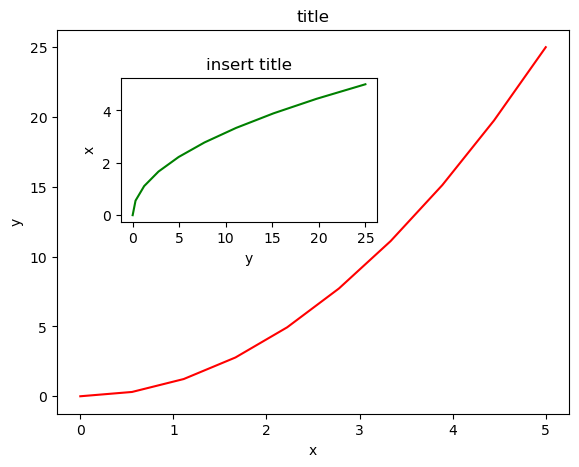

In [24]:
fig = plt.figure() #this line creates a new figure, so that the next plot command will be drawn in this new figure "fig".
print("fig:", fig)
print("x:", x)
print("y:", y)
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # main axes [left, bottom, width, height] in figure coordinates
axes2 = fig.add_axes([0.2, 0.5, 0.4, 0.3]) # inset axes [left, bottom, width, height] in figure coordinates
#axes2 starts at 20% from the left and 50% from the bottom of the figure, and is 40% as wide and 30% as tall as the figure.

# main figure
axes1.plot(x, y, 'r')
axes1.set_xlabel('x')
axes1.set_ylabel('y')
axes1.set_title('title')

# insert
axes2.plot(y, x, 'g')
axes2.set_xlabel('y')
axes2.set_ylabel('x')
axes2.set_title('inset title');

If we don't care about being explicit about where our plot axes are placed in the figure canvas, then we can use one of the many axis layout managers in matplotlib. My favorite is `subplots`, which can be used like this:

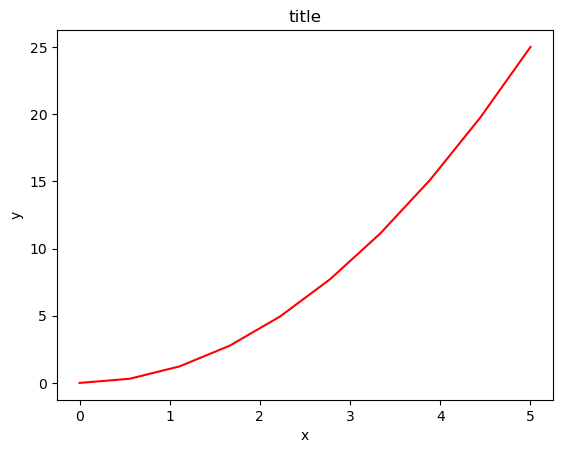

In [25]:
fig, axes = plt.subplots()  # shortcut: creates a figure AND one axes object in a single call

axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title');

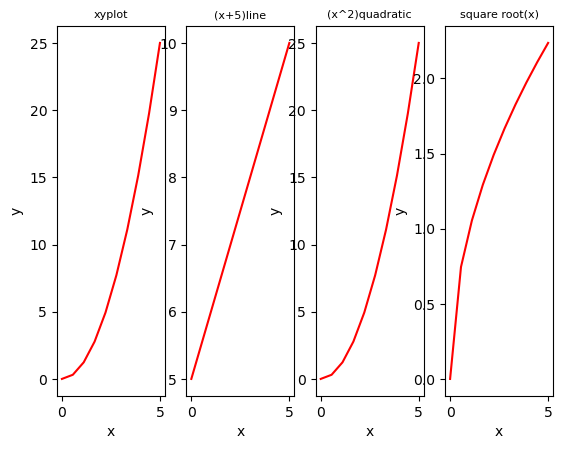

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=4)  # 1 row, 4 columns -> axes is now an array of 4 Axes objects
datasets=[(x, y, 'xyplot'),(x,x+5, '(x+5)line'), (x, x**2, '(x^2)quadratic'), (x, np.sqrt(x), 'square root(x)')]  # list of datasets to plot in each subplot
datasetcount = 0
for ax in axes:           # loop over each subplot and set it up identically
    ax.plot(datasets[datasetcount][0], datasets[datasetcount][1], 'r')  # plot the first dataset (x, y) in red
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(datasets[datasetcount][2],fontsize=8);
    datasetcount +=1
fig.savefig('my_figure_subplots.png') # save BEFORE show() -- see note below
fig.savefig('my_figure_subplots.pdf') # save BEFORE show() -- see note below
fig.savefig('my_figure_subplots.svg') # save BEFORE show() -- see note below
fig.savefig('my_figure_subplots.jpg') # save BEFORE show() -- see note below
show() # display AFTER saving. But it is showing without show() but it is needed in .py file, perhaps not in jupyter notebook.

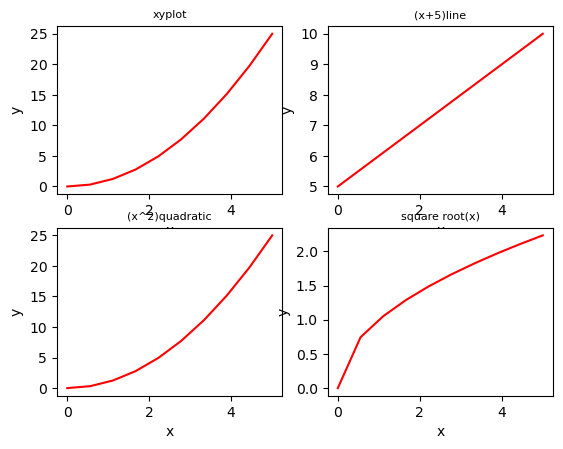

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2)  # 2 row, 2 columns -> axes is now an array of 2X 2 Axes objects
datasets=[(x, y, 'xyplot'),(x,x+5, '(x+5)line'), (x, x**2, '(x^2)quadratic'), (x, np.sqrt(x), 'square root(x)')]  # list of datasets to plot in each subplot
datasetcount = 0
#for ax in axes:           # loop over each subplot and set it up identically
for ax in axes.flat: 
    ax.plot(datasets[datasetcount][0], datasets[datasetcount][1], 'r')  # plot the first dataset (x, y) in red
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(datasets[datasetcount][2],fontsize=8);
    datasetcount +=1
fig.savefig('my_figure_subplots22.png') # save BEFORE show() -- see note below

show() # display AFTER saving. But it is showing without show() but it is needed in .py file, perhaps not in jupyter notebook.

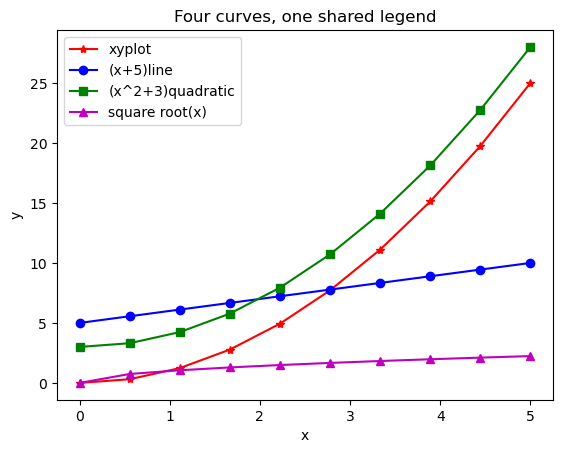

In [51]:
fig, axes = plt.subplots()

# List of datasets to plot -- each tuple holds (x-values, y-values, label-for-legend)
datasets = [(x, y, 'xyplot','r','*'),
            (x, x+5, '(x+5)line','b','o'),
            (x, x**2+3, '(x^2+3)quadratic','g','s'),
            (x, np.sqrt(x), 'square root(x)','m','^')]

for data in datasets:
    # unpack the tuple into three separate names -- plot() needs x and y as
    # SEPARATE arguments, not as one combined tuple (see earlier note on this)
    xi, yi, title, color, marker = data
    axes.plot(xi, yi, color=color, marker=marker)
    # no label= here -- labels are added all at once below, via legend()

# axes.legend() (not bare legend()) -- stays consistent with the object-oriented
# style used everywhere else in this cell, rather than relying on the leftover
# `from pylab import *` import from the earlier MATLAB-API section
#
# [data[2] for data in datasets]: pulls out just the label (3rd item) from every
# tuple, in dataset order. This 'data' is a NEW variable, scoped only to this
# list comprehension -- it does not clash with the 'data' used in the for-loop
# above, even though they share a name. Labels line up correctly with the curves
# because both the loop above and this comprehension walk `datasets` in the
# same order.
axes.legend([data[2] for data in datasets])

axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('Four curves, one shared legend')

fig.savefig('my_figure_subplots_all1.png')  # save BEFORE show()
show()  # no-op in this notebook (inline backend auto-displays); required in a .py script

That was easy, but it isn't so pretty with overlapping figure axes and labels, right?

We can deal with that by using the `fig.tight_layout` method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

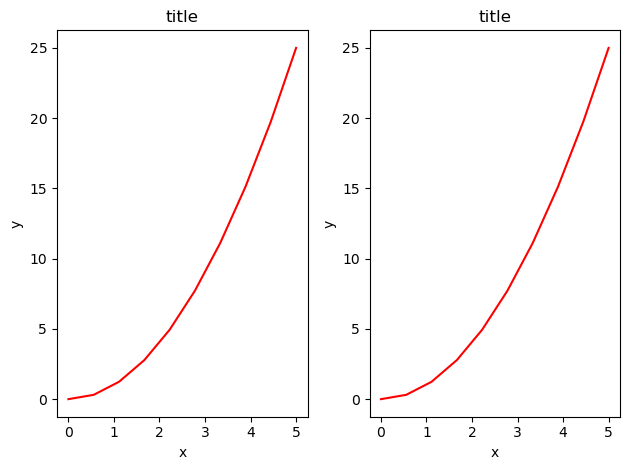

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=2)

for ax in axes:
    ax.plot(x, y, 'r')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('title')

fig.tight_layout()  # auto-adjusts spacing so titles/labels don't overlap between subplots

### Figure size, aspect ratio and DPI

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the `Figure` object is created, using the `figsize` and `dpi` keyword arguments. `figsize` is a tuple of the width and height of the figure in inches, and `dpi` is the dots-per-inch (pixel per inch). To create an 800x400 pixel, 100 dots-per-inch figure, we can do: 

In [ ]:
fig = plt.figure(figsize=(8,4), dpi=100)  # figsize in inches (width, height); dpi = dots per inch (resolution)

The same arguments can also be passed to layout managers, such as the `subplots` function:

In [ ]:
fig, axes = plt.subplots(figsize=(12,3))  # figsize/dpi can be passed to subplots() too, not just figure()

axes.plot(x, y, 'r')
axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_title('title');

### Saving figures

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [ ]:
fig.savefig("filename.png")  # format is inferred from the file extension

Here we can also optionally specify the DPI and choose between different output formats:

In [ ]:
fig.savefig("filename.png", dpi=200)  # override the figure's dpi just for this saved file

#### What formats are available and which ones should be used for best quality?

Matplotlib can generate high-quality output in a number formats, including PNG, JPG, EPS, SVG, PGF and PDF. For scientific papers, I recommend using PDF whenever possible. (LaTeX documents compiled with `pdflatex` can include PDFs using the `includegraphics` command). In some cases, PGF can also be good alternative.

### Legends, labels and titles

Now that we have covered the basics of how to create a figure canvas and add axes instances to the canvas, let's look at how decorate a figure with titles, axis labels, and legends.

**Figure titles**

A title can be added to each axis instance in a figure. To set the title, use the `set_title` method in the axes instance:

In [ ]:
ax.set_title("title");  # figure-level: use fig.suptitle() instead; this sets the title of THIS axes only

**Axis labels**

Similarly, with the methods `set_xlabel` and `set_ylabel`, we can set the labels of the X and Y axes:

In [ ]:
ax.set_xlabel("x")
ax.set_ylabel("y");

**Legends**

Legends for curves in a figure can be added in two ways. One method is to use the `legend` method of the axis object and pass a list/tuple of legend texts for the previously defined curves:

In [ ]:
ax.legend(["curve1", "curve2", "curve3"]);  # MATLAB-style: order must exactly match the order plot() was called in

The method described above follows the MATLAB API. It is somewhat prone to errors and unflexible if curves are added to or removed from the figure (resulting in a wrongly labelled curve).

A better method is to use the `label="label text"` keyword argument when plots or other objects are added to the figure, and then using the `legend` method without arguments to add the legend to the figure: 

In [ ]:
ax.plot(x, x**2, label="curve1")  # label= is attached to the line itself, at plot time
ax.plot(x, x**3, label="curve2")
ax.legend();  # legend() then just collects every labeled line automatically -- order-proof, unlike cell above

The advantage with this method is that if curves are added or removed from the figure, the legend is automatically updated accordingly.

The `legend` function takes an optional keyword argument `loc` that can be used to specify where in the figure the legend is to be drawn. The allowed values of `loc` are numerical codes for the various places the legend can be drawn. See http://matplotlib.org/users/legend_guide.html#legend-location for details. Some of the most common `loc` values are:

In [22]:
ax.legend(loc=0) # let matplotlib decide the optimal location
ax.legend(loc=1) # upper right corner
ax.legend(loc=2) # upper left corner
ax.legend(loc=3) # lower left corner
ax.legend(loc=4) # lower right corner
# .. many more options are available

The following figure shows how to use the figure title, axis labels and legends described above:

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label="y = x**2")
ax.plot(x, x**3, label="y = x**3")
ax.legend(loc=2); # upper left corner
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('title');

### Formatting text: LaTeX, fontsize, font family

The figure above is functional, but it does not (yet) satisfy the criteria for a figure used in a publication. First and foremost, we need to have LaTeX formatted text, and second, we need to be able to adjust the font size to appear right in a publication.

Matplotlib has great support for LaTeX. All we need to do is to use dollar signs encapsulate LaTeX in any text (legend, title, label, etc.). For example, `"$y=x^3$"`.

But here we can run into a slightly subtle problem with LaTeX code and Python text strings. In LaTeX, we frequently use the backslash in commands, for example `\alpha` to produce the symbol $\alpha$. But the backslash already has a meaning in Python strings (the escape code character). To avoid Python messing up our latex code, we need to use "raw" text strings. Raw text strings are prepended with an '`r`', like `r"\alpha"` or `r'\alpha'` instead of `"\alpha"` or `'\alpha'`:

In [ ]:
fig, ax = plt.subplots()

# r"$...$" is a raw string containing LaTeX math -- matplotlib renders it as proper math typesetting
ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$', fontsize=18)
ax.set_ylabel(r'$y$', fontsize=18)
ax.set_title('title');

We can also change the global font size and font family, which applies to all text elements in a figure (tick labels, axis labels and titles, legends, etc.):

In [25]:
# Update the matplotlib configuration parameters:
matplotlib.rcParams.update({'font.size': 18, 'font.family': 'serif'})

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$')  # font.size is now 18 globally (set in previous cell), so no need to repeat fontsize= here
ax.set_ylabel(r'$y$')
ax.set_title('title');

A good choice of global fonts are the STIX fonts: 

In [27]:
# Update the matplotlib configuration parameters:
matplotlib.rcParams.update({'font.size': 18, 'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix'})

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$')  # STIX font now applies globally -- notice the math symbols look different from above
ax.set_ylabel(r'$y$')
ax.set_title('title');

Or, alternatively, we can request that matplotlib uses LaTeX to render the text elements in the figure:

In [29]:
matplotlib.rcParams.update({'font.size': 18, 'text.usetex': True})

In [ ]:
fig, ax = plt.subplots()  # this figure is now rendered using a real LaTeX installation (text.usetex=True) --
# slower to render, but every glyph matches your LaTeX documents exactly.

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2) # upper left corner
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$y$')
ax.set_title('title');

In [31]:
# restore
matplotlib.rcParams.update({'font.size': 12, 'font.family': 'sans', 'text.usetex': False})

### Setting colors, linewidths, linetypes

#### Colors

With matplotlib, we can define the colors of lines and other graphical elements in a number of ways. First of all, we can use the MATLAB-like syntax where `'b'` means blue, `'g'` means green, etc. The MATLAB API for selecting line styles are also supported: where, for example, 'b.-' means a blue line with dots:

In [32]:
# MATLAB style line color and style 
ax.plot(x, x**2, 'b.-') # blue line with dots
ax.plot(x, x**3, 'g--') # green dashed line

We can also define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments:

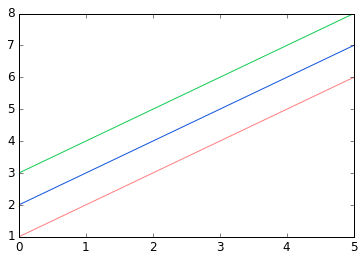

In [33]:
fig, ax = plt.subplots()

ax.plot(x, x+1, color="red", alpha=0.5) # half-transparent red
ax.plot(x, x+2, color="#1155dd")        # RGB hex code for a bluish color
ax.plot(x, x+3, color="#15cc55")        # RGB hex code for a greenish color

#### Line and marker styles

To change the line width, we can use the `linewidth` or `lw` keyword argument. The line style can be selected using the `linestyle` or `ls` keyword arguments:

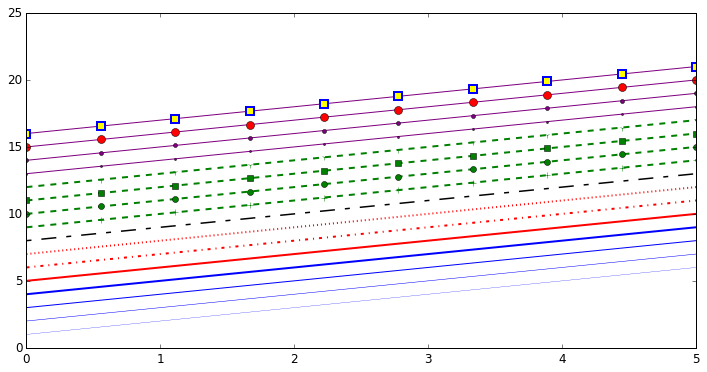

In [34]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x, x+1, color="blue", linewidth=0.25)
ax.plot(x, x+2, color="blue", linewidth=0.50)
ax.plot(x, x+3, color="blue", linewidth=1.00)
ax.plot(x, x+4, color="blue", linewidth=2.00)

# possible linestype options ‘-‘, ‘--’, ‘-.’, ‘:’, ‘steps’
ax.plot(x, x+5, color="red", lw=2, linestyle='-')
ax.plot(x, x+6, color="red", lw=2, ls='-.')
ax.plot(x, x+7, color="red", lw=2, ls=':')

# custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10]) # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="green", lw=2, ls='--', marker='+')
ax.plot(x, x+10, color="green", lw=2, ls='--', marker='o')
ax.plot(x, x+11, color="green", lw=2, ls='--', marker='s')
ax.plot(x, x+12, color="green", lw=2, ls='--', marker='1')

# marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=2, markeredgecolor="blue");

### Control over axis appearance

The appearance of the axes is an important aspect of a figure that we often need to modify to make a publication quality graphics. We need to be able to control where the ticks and labels are placed, modify the font size and possibly the labels used on the axes. In this section we will look at controlling those properties in a matplotlib figure.

#### Plot range

The first thing we might want to configure is the ranges of the axes. We can do this using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatically getting "tightly fitted" axes ranges:

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x, x**2, x, x**3)
axes[0].set_title("default axes ranges")  # matplotlib auto-pads a small margin around the data

axes[1].plot(x, x**2, x, x**3)
axes[1].axis('tight')                     # 'tight': shrink the range to fit the data exactly, no padding
axes[1].set_title("tight axes")

axes[2].plot(x, x**2, x, x**3)
axes[2].set_ylim([0, 60])                 # or set exact numeric limits yourself
axes[2].set_xlim([2, 5])
axes[2].set_title("custom axes range");

#### Logarithmic scale

It is also possible to set a logarithmic scale for one or both axes. This functionality is in fact only one application of a more general transformation system in Matplotlib. Each of the axes' scales are set seperately using `set_xscale` and `set_yscale` methods which accept one parameter (with the value "log" in this case):

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].plot(x, x**2, x, np.exp(x))
axes[0].set_title("Normal scale")

axes[1].plot(x, x**2, x, np.exp(x))
axes[1].set_yscale("log")                          # compress the fast-growing exp(x) curve onto a readable scale
axes[1].set_title("Logarithmic scale (y)");         # use set_xscale("log") the same way for the x-axis

### Placement of ticks and custom tick labels

We can explicitly determine where we want the axis ticks with `set_xticks` and `set_yticks`, which both take a list of values for where on the axis the ticks are to be placed. We can also use the `set_xticklabels` and `set_yticklabels` methods to provide a list of custom text labels for each tick location:

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, x**2, x, x**3, lw=2)

ax.set_xticks([1, 2, 3, 4, 5])  # choose exactly where tick marks appear
ax.set_xticklabels([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$\delta$', r'$\epsilon$'], fontsize=18)  # ...and what text labels them

yticks = [0, 50, 100, 150]
ax.set_yticks(yticks)
ax.set_yticklabels(["$%.1f$" % y for y in yticks], fontsize=18); # use LaTeX formatted labels

There are a number of more advanced methods for controlling major and minor tick placement in matplotlib figures, such as automatic placement according to different policies. See http://matplotlib.org/api/ticker_api.html for details.

#### Scientific notation

This is our first use of `matplotlib.ticker` — the submodule responsible for *where* tick marks are placed and *how* their labels are formatted. You've already used it indirectly (`set_xticks`/`set_xticklabels` above are the manual, do-it-yourself version); `ticker` gives you automatic, rule-based control instead:

- **`ticker.MultipleLocator(n)`** — place a tick every `n` units, automatically, no matter the range.
- **`ticker.MaxNLocator(n)`** — let matplotlib choose "nice" tick positions, capped at roughly `n` ticks.
- **`ticker.FuncFormatter(func)`** — format each tick label with your own function, e.g. to show `π/2` instead of `1.57`.
- **`ticker.ScalarFormatter`** (used below) — the default numeric formatter, here told to switch to scientific notation once numbers get large.

With large numbers on axes, it is often better use scientific notation:

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_title("scientific notation")

ax.set_yticks([0, 50, 100, 150])

from matplotlib import ticker
formatter = ticker.ScalarFormatter(useMathText=True)  # useMathText: render as $1.5 \times 10^2$, not "1.5e2"
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))   # switch to scientific notation once values fall outside 10^-1 .. 10^1
ax.yaxis.set_major_formatter(formatter)  # apply this formatter to the y-axis's major ticks

### Axis number and axis label spacing

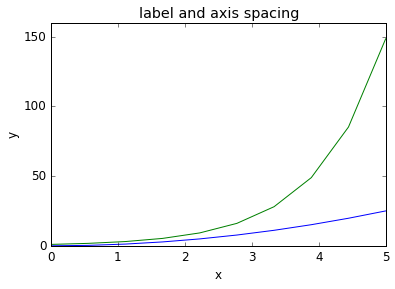

In [39]:
# distance between x and y axis and the numbers on the axes
matplotlib.rcParams['xtick.major.pad'] = 5
matplotlib.rcParams['ytick.major.pad'] = 5

fig, ax = plt.subplots(1, 1)
      
ax.plot(x, x**2, x, np.exp(x))
ax.set_yticks([0, 50, 100, 150])

ax.set_title("label and axis spacing")

# padding between axis label and axis numbers
ax.xaxis.labelpad = 5
ax.yaxis.labelpad = 5

ax.set_xlabel("x")
ax.set_ylabel("y");

In [40]:
# restore defaults
matplotlib.rcParams['xtick.major.pad'] = 3
matplotlib.rcParams['ytick.major.pad'] = 3

#### Axis position adjustments

Unfortunately, when saving figures the labels are sometimes clipped, and it can be necessary to adjust the positions of axes a little bit. This can be done using `subplots_adjust`:

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_yticks([0, 50, 100, 150])

ax.set_title("title")
ax.set_xlabel("x")
ax.set_ylabel("y")

# manually control the margins around the axes (fractions of the full figure, 0 to 1)
fig.subplots_adjust(left=0.15, right=.9, bottom=0.1, top=0.9);

### Axis grid

With the `grid` method in the axis object, we can turn on and off grid lines. We can also customize the appearance of the grid lines using the same keyword arguments as the `plot` function:

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,3))

# default grid appearance
axes[0].plot(x, x**2, x, x**3, lw=2)
axes[0].grid(True)

# custom grid appearance -- grid() accepts the same style keywords as plot()
axes[1].plot(x, x**2, x, x**3, lw=2)
axes[1].grid(color='b', alpha=0.5, linestyle='dashed', linewidth=0.5)

### Axis spines

We can also change the properties of axis spines:

In [ ]:
fig, ax = plt.subplots(figsize=(6,2))

# "spines" are the box lines around the plot -- top, bottom, left, right -- each editable independently
ax.spines['bottom'].set_color('blue')
ax.spines['top'].set_color('blue')

ax.spines['left'].set_color('red')
ax.spines['left'].set_linewidth(2)

# turn off axis spine to the right
ax.spines['right'].set_color("none")
ax.yaxis.tick_left() # only ticks on the left side

### Twin axes

Sometimes it is useful to have dual x or y axes in a figure; for example, when plotting curves with different units together. Matplotlib supports this with the `twinx` and `twiny` functions:

In [ ]:
fig, ax1 = plt.subplots()

# left y-axis: area, in blue
ax1.plot(x, x**2, lw=2, color="blue")
ax1.set_ylabel(r"area $(m^2)$", fontsize=18, color="blue")
for label in ax1.get_yticklabels():
    label.set_color("blue")

# twinx(): a second y-axis sharing the same x-axis, so two different quantities/scales can share one plot
ax2 = ax1.twinx()
ax2.plot(x, x**3, lw=2, color="red")
ax2.set_ylabel(r"volume $(m^3)$", fontsize=18, color="red")
for label in ax2.get_yticklabels():
    label.set_color("red")

### Axes where x and y is zero

In [ ]:
fig, ax = plt.subplots()

# hide the top and right box lines entirely
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_ticks_position('bottom')
ax.spines['bottom'].set_position(('data',0)) # set position of x spine to x=0

ax.yaxis.set_ticks_position('left')
ax.spines['left'].set_position(('data',0))   # set position of y spine to y=0
# the two lines above move the axes themselves to cross at the origin -- a "math textbook" style plot

xx = np.linspace(-0.75, 1., 100)
ax.plot(xx, xx**3);

### Other 2D plot styles

In addition to the regular `plot` method, there are a number of other functions for generating different kind of plots. See the matplotlib plot gallery for a complete list of available plot types: http://matplotlib.org/gallery.html. Some of the more useful ones are show below:

In [ ]:
n = np.array([0,1,2,3,4,5])  # small integer array, used below for step/bar plots (discrete data, not continuous)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

axes[0].scatter(xx, xx + 0.25*np.random.randn(len(xx)))  # unconnected points -- for data without an implied order
axes[0].set_title("scatter")

axes[1].step(n, n**2, lw=2)                                # constant between points, then jumps -- for discrete/count data
axes[1].set_title("step")

axes[2].bar(n, n**2, align="center", width=0.5, alpha=0.5) # bars -- for comparing discrete categories
axes[2].set_title("bar")

axes[3].fill_between(x, x**2, x**3, color="green", alpha=0.5); # shades the region BETWEEN two curves
axes[3].set_title("fill_between");

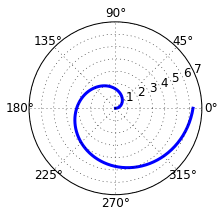

In [48]:
# polar plot using add_axes and polar projection
fig = plt.figure()
ax = fig.add_axes([0.0, 0.0, .6, .6], polar=True)
t = np.linspace(0, 2 * np.pi, 100)
ax.plot(t, t, color='blue', lw=3);

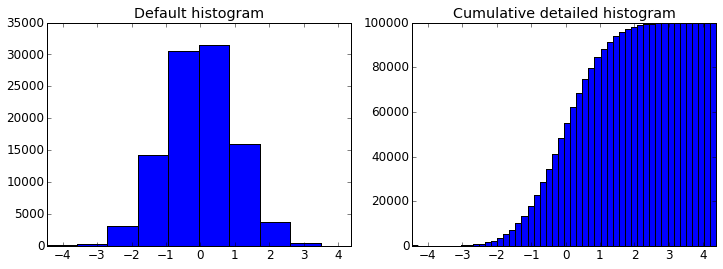

In [49]:
# A histogram
n = np.random.randn(100000)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].hist(n)
axes[0].set_title("Default histogram")
axes[0].set_xlim((min(n), max(n)))

axes[1].hist(n, cumulative=True, bins=50)
axes[1].set_title("Cumulative detailed histogram")
axes[1].set_xlim((min(n), max(n)));

### Text annotation

Annotating text in matplotlib figures can be done using the `text` function. It supports LaTeX formatting just like axis label texts and titles:

In [ ]:
fig, ax = plt.subplots()

ax.plot(xx, xx**2, xx, xx**3)

# ax.text(x, y, string): places text at DATA coordinates (0.15, 0.2), not pixel/figure coordinates
ax.text(0.15, 0.2, r"$y=x^2$", fontsize=20, color="blue")
ax.text(0.65, 0.1, r"$y=x^3$", fontsize=20, color="green");

### Figures with multiple subplots and insets

Axes can be added to a matplotlib Figure canvas manually using `fig.add_axes` or using a sub-figure layout manager such as `subplots`, `subplot2grid`, or `gridspec`:

#### subplots

In [ ]:
fig, ax = plt.subplots(2, 3)  # a uniform 2x3 grid -- the simplest way to lay out several equal-size subplots
fig.tight_layout()

#### subplot2grid

In [ ]:
fig = plt.figure()
# subplot2grid((rows, cols), (row_start, col_start), rowspan=, colspan=) -- for grids where panels
# need to span multiple rows or columns unevenly, which plt.subplots() alone can't do
ax1 = plt.subplot2grid((3,3), (0,0), colspan=3)
ax2 = plt.subplot2grid((3,3), (1,0), colspan=2)
ax3 = plt.subplot2grid((3,3), (1,2), rowspan=2)
ax4 = plt.subplot2grid((3,3), (2,0))
ax5 = plt.subplot2grid((3,3), (2,1))
fig.tight_layout()

#### gridspec

In [53]:
import matplotlib.gridspec as gridspec

In [ ]:
fig = plt.figure()

# gridspec: similar goal to subplot2grid, but lets you also set relative row/column SIZES, not just spans
gs = gridspec.GridSpec(2, 3, height_ratios=[2,1], width_ratios=[1,2,1])
for g in gs:
    ax = fig.add_subplot(g)

fig.tight_layout()

#### add_axes

Manually adding axes with `add_axes` is useful for adding insets to figures:

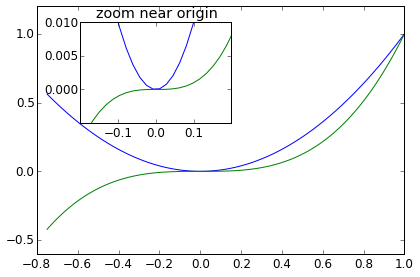

In [55]:
fig, ax = plt.subplots()

ax.plot(xx, xx**2, xx, xx**3)
fig.tight_layout()

# inset
inset_ax = fig.add_axes([0.2, 0.55, 0.35, 0.35]) # X, Y, width, height

inset_ax.plot(xx, xx**2, xx, xx**3)
inset_ax.set_title('zoom near origin')

# set axis range
inset_ax.set_xlim(-.2, .2)
inset_ax.set_ylim(-.005, .01)

# set axis tick locations
inset_ax.set_yticks([0, 0.005, 0.01])
inset_ax.set_xticks([-0.1,0,.1]);

### Colormap and contour figures

Colormaps and contour figures are useful for plotting functions of two variables. In most of these functions we will use a colormap to encode one dimension of the data. There are a number of predefined colormaps. It is relatively straightforward to define custom colormaps. For a list of pre-defined colormaps, see: http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps

In [ ]:
alpha = 0.7
phi_ext = 2 * np.pi * 0.5

# a real physics example: the potential energy landscape of a flux qubit, as a function of two phase
# variables phi_m, phi_p. This is exactly the kind of two-variable function colormaps/contours are for.
def flux_qubit_potential(phi_m, phi_p):
    return 2 + alpha - 2 * np.cos(phi_p) * np.cos(phi_m) - alpha * np.cos(phi_ext - 2*phi_p)

In [ ]:
phi_m = np.linspace(0, 2*np.pi, 100)
phi_p = np.linspace(0, 2*np.pi, 100)
X,Y = np.meshgrid(phi_p, phi_m)   # build the 2D grid of (phi_p, phi_m) coordinate pairs
Z = flux_qubit_potential(X, Y).T  # evaluate the potential at every grid point -> a 2D array of values

#### pcolor

In [ ]:
fig, ax = plt.subplots()

# pcolor: colors each grid CELL according to its Z value -- good for showing exact value at every point
p = ax.pcolor(X/(2*np.pi), Y/(2*np.pi), Z, cmap=matplotlib.cm.RdBu, vmin=abs(Z).min(), vmax=abs(Z).max())
cb = fig.colorbar(p, ax=ax)  # colorbar: the legend mapping colors back to numeric Z values

#### imshow

In [ ]:
fig, ax = plt.subplots()

# imshow: treats Z as an image (faster to render than pcolor for large grids, but assumes a regular grid)
im = ax.imshow(Z, cmap=matplotlib.cm.RdBu, vmin=abs(Z).min(), vmax=abs(Z).max(), extent=[0, 1, 0, 1])
im.set_interpolation('bilinear')  # smooths between grid cells instead of showing hard pixel edges

cb = fig.colorbar(im, ax=ax)

#### contour

In [ ]:
fig, ax = plt.subplots()

# contourf: draws filled bands between fixed Z levels, like a topographic map -- easier to read discrete
# value ranges from than pcolor/imshow's continuous shading
cnt = ax.contourf(X, Y, Z, cmap=matplotlib.cm.RdBu, vmin=abs(Z).min(), vmax=abs(Z).max(), extent=[0, 1, 0, 1])

## 3D figures

To use 3D graphics in matplotlib, we first need to create an instance of the `Axes3D` class. 3D axes can be added to a matplotlib figure canvas in exactly the same way as 2D axes; or, more conveniently, by passing a `projection='3d'` keyword argument to the `add_axes` or `add_subplot` methods.

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D  # required once, before requesting projection='3d' below

#### Surface plots

In [ ]:
fig = plt.figure(figsize=(14,6))

# `ax` is a 3D-aware axis instance because of the projection='3d' keyword argument to add_subplot
ax = fig.add_subplot(1, 2, 1, projection='3d')

# rstride/cstride: "row/column stride" -- how many grid points to skip between drawn surface lines
# (higher stride = coarser but faster-to-render mesh)
p = ax.plot_surface(X, Y, Z, rstride=4, cstride=4, linewidth=0)

# surface_plot with color grading and color bar
ax = fig.add_subplot(1, 2, 2, projection='3d')
p = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=matplotlib.cm.coolwarm, linewidth=0, antialiased=False)
cb = fig.colorbar(p, shrink=0.5)

#### Wire-frame plot

In [ ]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(1, 1, 1, projection='3d')

# wireframe: just the mesh lines, no filled surface -- useful when you want to see through to what's behind
p = ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4)

#### Coutour plots with projections

In [ ]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(1,1,1, projection='3d')

ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)  # semi-transparent surface, so the projected
                                                               # contours below remain visible through it

# zdir='z'/'x'/'y' + offset: projects a 2D contour of the surface onto a flat wall of the 3D box --
# useful for reading off the surface's shape from each axis, like blueprints of a 3D object
cset = ax.contour(X, Y, Z, zdir='z', offset=-np.pi, cmap=matplotlib.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='x', offset=-np.pi, cmap=matplotlib.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir='y', offset=3*np.pi, cmap=matplotlib.cm.coolwarm)

ax.set_xlim3d(-np.pi, 2*np.pi);
ax.set_ylim3d(0, 3*np.pi);
ax.set_zlim3d(-np.pi, 2*np.pi);

#### Change the view angle

We can change the perspective of a 3D plot using the `view_init` method, which takes two arguments: `elevation` and `azimuth` angle (in degrees):

In [ ]:
fig = plt.figure(figsize=(12,6))

ax = fig.add_subplot(1,2,1, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(30, 45)  # view_init(elevation, azimuth) in degrees -- rotates the camera around the plot

ax = fig.add_subplot(1,2,2, projection='3d')
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(70, 30)  # a much steeper, more top-down view of the same surface

fig.tight_layout()

### Animations

Matplotlib also includes a simple API for generating animations for sequences of figures. With the `FuncAnimation` function we can generate a movie file from sequences of figures. The function takes the following arguments: `fig`, a figure canvas, `func`, a function that we provide which updates the figure, `init_func`, a function we provide to setup the figure, `frame`, the number of frames to generate, and `blit`, which tells the animation function to only update parts of the frame which have changed (for smoother animations):

    def init():
        # setup figure

    def update(frame_counter):
        # update figure for new frame

    anim = animation.FuncAnimation(fig, update, init_func=init, frames=200, blit=True)

    anim.save('animation.mp4', fps=30) # fps = frames per second

To use the animation features in matplotlib we first need to import the module `matplotlib.animation`:

In [66]:
from matplotlib import animation

In [ ]:
# solve the ODE for a double compound pendulum -- a classic chaotic system.
# x1, x2 = angles of the two pendulum arms; x3, x4 = their angular momenta.
# The animation below just plays back this pre-computed trajectory frame by frame.

from scipy.integrate import odeint
from numpy import cos, sin

g = 9.82; L = 0.5; m = 0.1  # gravity, arm length, mass -- same for both arms

def dx(x, t):
    x1, x2, x3, x4 = x[0], x[1], x[2], x[3]

    dx1 = 6.0/(m*L**2) * (2 * x3 - 3 * cos(x1-x2) * x4)/(16 - 9 * cos(x1-x2)**2)
    dx2 = 6.0/(m*L**2) * (8 * x4 - 3 * cos(x1-x2) * x3)/(16 - 9 * cos(x1-x2)**2)
    dx3 = -0.5 * m * L**2 * ( dx1 * dx2 * sin(x1-x2) + 3 * (g/L) * sin(x1))
    dx4 = -0.5 * m * L**2 * (-dx1 * dx2 * sin(x1-x2) + (g/L) * sin(x2))
    return [dx1, dx2, dx3, dx4]

x0 = [np.pi/2, np.pi/2, 0, 0]  # initial state: both arms horizontal, at rest
t = np.linspace(0, 10, 250)    # time coordinates: 250 frames over 10 seconds
x = odeint(dx, x0, t)          # solve the ODE -- x[n] is the full state at frame n

Generate an animation that shows the positions of the pendulums as a function of time:

In [ ]:
fig, ax = plt.subplots(figsize=(5,5))

ax.set_ylim([-1.5, 0.5])
ax.set_xlim([1, -1])  # x-axis reversed: matches how the pendulum's angle convention points

# empty line objects now, filled in frame by frame by update() below
pendulum1, = ax.plot([], [], color="red", lw=2)
pendulum2, = ax.plot([], [], color="blue", lw=2)

def init():
    """Called once, before the first frame -- clears both lines to empty."""
    pendulum1.set_data([], [])
    pendulum2.set_data([], [])
    return pendulum1, pendulum2

def update(n):
    # n = frame counter, indexes into the trajectory x[] solved above
    # calculate the positions of the pendulums
    x1 = + L * sin(x[n, 0])
    y1 = - L * cos(x[n, 0])
    x2 = x1 + L * sin(x[n, 1])
    y2 = y1 - L * cos(x[n, 1])

    # update the line data -- redraw each pendulum arm from its pivot to its current tip
    pendulum1.set_data([0 ,x1], [0 ,y1])
    pendulum2.set_data([x1,x2], [y1,y2])

    return pendulum1, pendulum2

# blit=True: only redraw the parts of the figure that changed -- much faster for animations
anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(t), blit=True)

# anim.save can be called in a few different ways, some which might or might not work
# on different platforms and with different versions of matplotlib and video encoders
#anim.save('animation.mp4', fps=20, extra_args=['-vcodec', 'libx264'], writer=animation.FFMpegWriter())
#anim.save('animation.mp4', fps=20, extra_args=['-vcodec', 'libx264'])
anim.save('animation.mp4', fps=20, writer="ffmpeg", codec="libx264")  # requires ffmpeg installed separately
#anim.save('animation.mp4', fps=20, writer="avconv", codec="libx264")

plt.close(fig)  # prevents a duplicate static figure from also being displayed below the animation

Note: To generate the movie file we need to have either `ffmpeg` or `avconv` installed. Install it on Ubuntu using:

    $ sudo apt-get install ffmpeg

or (newer versions)

    $ sudo apt-get install libav-tools

On MacOSX, try: 

    $ sudo port install ffmpeg

In [ ]:
# Display animation using HTML element -- embeds the saved .mp4 as a playable video right in the notebook
from IPython.display import HTML

HTML("""
    <video alt="test" controls>
        <source src="animation.mp4" type="video/mp4">
    </video>
""")

# OR use Video class -- a shorter, more modern equivalent of the HTML() call above
#from IPython.display import Video
#Video("animation.mp4")

### Backends

Matplotlib has a number of "backends" which are responsible for rendering graphs. The different backends are able to generate graphics with different formats and display/event loops. There is a distinction between noninteractive backends (such as 'agg', 'svg', 'pdf', etc.) that are only used to generate image files (e.g. with the `savefig` function), and interactive backends (such as qtagg, GTK, MaxOSX) that can display a GUI window for interactively exploring figures. 

A list of available backends are:

In [ ]:
# lists every rendering backend matplotlib ships with -- each one draws to a different target
# (a GUI window, a raster image, a vector file, etc.)
print(matplotlib.backends.backend_registry.list_builtin())

The default backend, called `agg`, is based on a library for raster graphics which is great for generating raster formats like PNG.

Normally we don't need to bother with changing the default backend; but sometimes it can be useful to switch to, for example, PDF or GTKCairo (if you are using Linux) to produce high-quality vector graphics instead of raster based graphics. 

#### Generating SVG with the svg backend

In [ ]:
# RESTART THE NOTEBOOK first: the backend can only be selected before matplotlib.pyplot is imported.
# (Kernel > Restart in VS Code/Jupyter)
import matplotlib
matplotlib.use('svg')  # 'svg' backend: renders to scalable vector graphics instead of raster pixels
import matplotlib.pylab as plt
import numpy
from IPython.display import Image, SVG

In [ ]:
# Now we are using the svg backend to produce SVG vector graphics
fig, ax = plt.subplots()
t = numpy.linspace(0, 10, 100)
ax.plot(t, numpy.cos(t)*numpy.sin(t))
plt.savefig("test.svg")  # written as a real vector file -- scales to any size with no pixelation

In [ ]:
# Show the produced SVG file inline in the notebook
SVG(filename="test.svg")

#### The IPython notebook inline backend

When we use IPython notebook it is convenient to use a matplotlib backend that outputs the graphics embedded in the notebook file. To activate this backend, somewhere in the beginning on the notebook, we add:

    %matplotlib inline

It is also possible to activate inline matplotlib plotting with:

    %pylab inline

The difference is that `%pylab inline` imports a number of packages into the global address space (scipy, numpy), while `%matplotlib inline` only sets up inline plotting. In new notebooks created for IPython 1.0+, I would recommend using `%matplotlib inline`, since it is tidier and you have more control over which packages are imported and how. Commonly, scipy and numpy are imported separately with:

    import numpy as np
    import scipy as sp
    import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='svg'  # tells the INLINE backend to render as SVG, not PNG --
                                             # crisp at any zoom level, unlike the default raster output

import matplotlib.pylab as plt
import numpy

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='svg'

import matplotlib.pylab as plt
import numpy

In [ ]:
# Now we are using SVG vector graphics displayed inline in the notebook
fig, ax = plt.subplots()
t = numpy.linspace(0, 10, 100)
ax.plot(t, numpy.cos(t)*numpy.sin(t))
plt.savefig("test.svg")

#### Interactive backend (this makes more sense in a python script file)

In [ ]:
# RESTART THE NOTEBOOK first: the backend can only be selected before matplotlib.pyplot is imported.
# (Kernel > Restart)
import matplotlib
matplotlib.use('qtagg')  # 'qtagg': an interactive GUI backend -- opens a real, resizable plot window
                          # (use 'MacOSX' instead on macOS)
import matplotlib.pylab as plt
import numpy as np

In [ ]:
# Now, open an interactive plot window with the qtagg backend --
# unlike the inline backend, this window supports live pan/zoom and stays open until you close it
fig, ax = plt.subplots()
t = np.linspace(0, 10, 100)
ax.plot(t, np.cos(t) * np.sin(t))
plt.show()

Note that when we use an interactive backend, we must call `plt.show()` to make the figure appear on the screen.

## Further reading

* http://www.matplotlib.org - The project web page for matplotlib.
* https://github.com/matplotlib/matplotlib - The source code for matplotlib.
* http://matplotlib.org/gallery.html - A large gallery showcaseing various types of plots matplotlib can create. Highly recommended! 
* http://www.loria.fr/~rougier/teaching/matplotlib - A good matplotlib tutorial.
* http://scipy-lectures.github.io/matplotlib/matplotlib.html - Another good matplotlib reference.


## Versions

In [1]:
%reload_ext watermark
%watermark -v -p numpy,scipy,matplotlib

Software versions
Python 2.7.10 64bit [GCC 4.2.1 (Apple Inc. build 5577)]
IPython 3.2.1
OS Darwin 14.1.0 x86_64 i386 64bit
numpy 1.9.2
scipy 0.16.0
matplotlib 1.4.3
Sat Aug 15 11:30:23 2015 JST